In [1]:
# ================================================================
# HyperCLAP — Section 12: PANNs CNN14 Backbone Validation
#
# Objectif : tester si la décomposition itérative Grassmannienne
# tient avec un backbone pré-entraîné (PANNs CNN14, AudioSet)
# au lieu de notre petit CNN entraîné from scratch.
#
# Protocole :
#   1. Charger CNN14 pré-entraîné sur AudioSet (frozen)
#   2. Ajouter tête subspace (QR) et tête point (L2-norm)
#   3. Entraîner seulement les têtes sur ESC-50 réduit
#   4. Phase 2 : alignment acoustique sur la tête subspace
#   5. Évaluer décomposition itérative class-level
#   6. Comparer avec point encoder sur même backbone
# ================================================================

## 0. Installation

In [2]:
!pip install -q datasets soundfile librosa
!pip install -q torch torchaudio

# Télécharger PANNs
!pip install -q panns-inference
print("done")

done


## 1. Imports & config

In [21]:
import numpy as np
import librosa
import random
import os
import requests
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from collections import defaultdict
from datasets import load_dataset

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
print(f"GPUs: {torch.cuda.device_count()}")

CFG = dict(
    n_mels=64,        # PANNs CNN14 attend 64 mels par défaut
    n_fft=1024,
    hop_length=320,
    sample_rate=32000, # PANNs CNN14 attend 32kHz
    k=4,
    d=128,            # plus grand car backbone plus puissant
    tau=0.1,
    lr=1e-3,          # lr plus élevé car seule la tête est entraînée
    batch_size=32,
)
TARGET_T    = 312     # ~10s à 32kHz avec hop=320 → 312 frames
N_CLASSES   = 10
EPOCHS_P1   = 60
EPOCHS_P2   = 60
LAM         = 2.0
N_MIX_TEST  = 400

Device: cuda
GPUs: 2


## 2. Télécharger CNN14 pré-entraîné

In [4]:
# Télécharger les poids CNN14 depuis le dépôt officiel PANNs
MODEL_URL  = "https://zenodo.org/record/3987831/files/Cnn14_mAP%3D0.431.pth"
MODEL_PATH = "/kaggle/working/Cnn14_mAP=0.431.pth"

if not os.path.exists(MODEL_PATH):
    print("Téléchargement CNN14...")
    r = requests.get(MODEL_URL, stream=True)
    with open(MODEL_PATH, "wb") as f:
        for chunk in r.iter_content(chunk_size=8192):
            f.write(chunk)
    print(f"Sauvegardé → {MODEL_PATH}")
else:
    print("Poids déjà présents.")

Téléchargement CNN14...
Sauvegardé → /kaggle/working/Cnn14_mAP=0.431.pth


## 3. Architecture CNN14 (version simplifiée pour extraction de features)

In [5]:
def init_layer(layer):
    nn.init.xavier_uniform_(layer.weight)
    if hasattr(layer, "bias") and layer.bias is not None:
        layer.bias.data.fill_(0.)

def init_bn(bn):
    bn.bias.data.fill_(0.)
    bn.weight.data.fill_(1.)

class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_channels)
        self.bn2   = nn.BatchNorm2d(out_channels)
        init_layer(self.conv1); init_layer(self.conv2)
        init_bn(self.bn1); init_bn(self.bn2)
    def forward(self, x, pool_size=(2,2), pool_type="avg"):
        x = F.relu_(self.bn1(self.conv1(x)))
        x = F.relu_(self.bn2(self.conv2(x)))
        if pool_type == "max":   x = F.max_pool2d(x, pool_size)
        elif pool_type == "avg": x = F.avg_pool2d(x, pool_size)
        else:                    x = F.avg_pool2d(x, pool_size) + F.max_pool2d(x, pool_size)
        return x

class Cnn14(nn.Module):
    def __init__(self):
        super().__init__()
        self.bn0   = nn.BatchNorm2d(64)
        self.conv0 = ConvBlock(1, 64)
        self.conv1 = ConvBlock(64, 128)
        self.conv2 = ConvBlock(128, 256)
        self.conv3 = ConvBlock(256, 512)
        self.conv4 = ConvBlock(512, 1024)
        self.conv5 = ConvBlock(1024, 2048)
        self.fc1   = nn.Linear(2048, 2048, bias=True)
        init_layer(self.fc1)

    def forward(self, x):
        # x : (B, n_mels, T)
        x = x.unsqueeze(1)                  # (B, 1, n_mels, T)
        x = x.transpose(1, 2)              # (B, n_mels, 1, T) — non, on transpose freq/time
        x = x.transpose(1, 3)              # (B, T, 1, n_mels)
        x = self.bn0(x.transpose(1, 3).transpose(2, 3))
        x = x.transpose(2, 3).transpose(1, 3)

        # Repasser en (B, 1, n_mels, T) pour les convolutions
        # La convention PANNs est (B, 1, mel, time)
        x = x.transpose(1, 3)              # → (B, n_mels, 1, T)
        x = x.transpose(1, 2)              # → (B, 1, n_mels, T) ✓

        x = self.conv0(x, pool_size=(2,2), pool_type="avg")
        x = F.dropout(x, p=0.2, training=self.training)
        x = self.conv1(x, pool_size=(2,2), pool_type="avg")
        x = F.dropout(x, p=0.2, training=self.training)
        x = self.conv2(x, pool_size=(2,2), pool_type="avg")
        x = F.dropout(x, p=0.2, training=self.training)
        x = self.conv3(x, pool_size=(2,2), pool_type="avg")
        x = F.dropout(x, p=0.2, training=self.training)
        x = self.conv4(x, pool_size=(2,2), pool_type="avg")
        x = F.dropout(x, p=0.2, training=self.training)
        x = self.conv5(x, pool_size=(1,1), pool_type="avg")
        x = F.dropout(x, p=0.2, training=self.training)

        x = torch.mean(x, dim=3)           # mean over time
        x1 = F.max_pool1d(x, kernel_size=3, stride=1, padding=1)
        x2 = F.avg_pool1d(x, kernel_size=3, stride=1, padding=1)
        x  = x1 + x2
        x  = F.dropout(x, p=0.5, training=self.training)
        x  = x.transpose(1, 2)
        x  = F.relu_(self.fc1(x))
        x  = x.mean(dim=1)                 # (B, 2048)
        return x                           # feature vector 2048-dim

In [6]:
# Charger les poids pré-entraînés
print("Chargement CNN14...")
backbone = Cnn14()
checkpoint = torch.load(MODEL_PATH, map_location="cpu")

# Les poids sont sous la clé "model"
state = checkpoint["model"]
# Filtrer uniquement les couches présentes dans notre backbone
# (enlever les couches de classification fc_audioset)
filtered = {k: v for k, v in state.items()
            if k in backbone.state_dict() and
            backbone.state_dict()[k].shape == v.shape}
backbone.load_state_dict(filtered, strict=False)
print(f"  Chargé {len(filtered)}/{len(backbone.state_dict())} couches")

# Geler le backbone — on n'entraîne que les têtes
for param in backbone.parameters():
    param.requires_grad = False
backbone.eval()
backbone = backbone.to(DEVICE)
print("Backbone CNN14 gelé et prêt.\n")

Chargement CNN14...
  Chargé 7/79 couches
Backbone CNN14 gelé et prêt.



## 4. Têtes de projection

In [7]:
class SubspaceHead(nn.Module):
    """Tête subspace : Linear → reshape → QR"""
    def __init__(self, in_dim=2048, d=128, k=4):
        super().__init__()
        self.d = d; self.k = k
        self.proj = nn.Sequential(
            nn.Linear(in_dim, 512), nn.GELU(),
            nn.Linear(512, d * k)
        )
    def forward(self, h):
        B = h.shape[0]
        z = self.proj(h).view(B, self.d, self.k)
        Z, _ = torch.linalg.qr(z)
        return Z   # (B, d, k)

class PointHead(nn.Module):
    """Tête point : Linear → L2-normalize"""
    def __init__(self, in_dim=2048, d=128):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(in_dim, 512), nn.GELU(),
            nn.Linear(512, d)
        )
    def forward(self, h):
        return F.normalize(self.proj(h), dim=-1)   # (B, d)

sub_head = SubspaceHead(in_dim=2048, d=CFG["d"], k=CFG["k"]).to(DEVICE)
pt_head  = PointHead(in_dim=2048, d=CFG["d"]).to(DEVICE)
print(f"SubspaceHead params: {sum(p.numel() for p in sub_head.parameters()):,}")
print(f"PointHead params   : {sum(p.numel() for p in pt_head.parameters()):,}")

SubspaceHead params: 1,311,744
PointHead params   : 1,114,752


## 5. Préparation des données

In [8]:
print("Loading ESC-50...")
esc50       = load_dataset("ashraq/esc50")
esc50_train = esc50["train"]

SR_TARGET = CFG["sample_rate"]   # 32kHz pour PANNs

def extract_logmel_panns(sample):
    w  = sample["audio"]["array"]
    sr = sample["audio"]["sampling_rate"]
    # Resample vers 32kHz
    if sr != SR_TARGET:
        w = librosa.resample(w, orig_sr=sr, target_sr=SR_TARGET)
    mel = librosa.feature.melspectrogram(
        y=w, sr=SR_TARGET,
        n_fft=CFG["n_fft"], hop_length=CFG["hop_length"],
        n_mels=CFG["n_mels"], fmin=50, fmax=14000)
    return librosa.power_to_db(mel, ref=np.max)   # (64, T)

def logmel_to_tensor(lm):
    lm = (lm - lm.min()) / (lm.max() - lm.min() + 1e-8) * 2 - 1
    return torch.tensor(lm, dtype=torch.float32)  # (64, T)

def pool_mel(t, target_T=TARGET_T):
    # t : (64, T) → (64, target_T)
    return F.adaptive_avg_pool1d(t.unsqueeze(0), target_T).squeeze(0)

def normalize_w(w):
    n = np.linalg.norm(w); return w / n if n > 1e-8 else w

print("Pre-computing log-mel spectrograms (32kHz, 64 mels)...")
all_logmels   = []
all_waveforms = []
all_categories = []

for i, sample in enumerate(esc50_train):
    all_logmels.append(extract_logmel_panns(sample))
    w  = sample["audio"]["array"]
    sr = sample["audio"]["sampling_rate"]
    if sr != SR_TARGET:
        w = librosa.resample(w, orig_sr=sr, target_sr=SR_TARGET)
    all_waveforms.append((w.astype(np.float32), SR_TARGET))
    all_categories.append(sample["category"])
    if (i+1) % 400 == 0: print(f"  {i+1}/{len(esc50_train)}")

categories    = sorted(set(all_categories))
cat2idx       = {c: i for i, c in enumerate(categories)}
all_label_ids = [cat2idx[c] for c in all_categories]
print("Done.\n")

Loading ESC-50...


README.md:   0%|          | 0.00/345 [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


dataset_infos.json: 0.00B [00:00, ?B/s]

data/train-00000-of-00002-2f1ab7b824ec75(…):   0%|          | 0.00/387M [00:00<?, ?B/s]

data/train-00001-of-00002-27425e5c1846b4(…):   0%|          | 0.00/387M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Pre-computing log-mel spectrograms (32kHz, 64 mels)...
  400/2000
  800/2000
  1200/2000
  1600/2000
  2000/2000
Done.



In [9]:
# Corpus réduit — 10 classes
selected_classes = sorted(set(all_categories))[:N_CLASSES]
print(f"Classes: {selected_classes}")

reduced_idx       = [i for i, c in enumerate(all_categories) if c in selected_classes]
reduced_logmels   = [all_logmels[i]   for i in reduced_idx]
reduced_waveforms = [all_waveforms[i] for i in reduced_idx]
reduced_labels    = [all_label_ids[i] for i in reduced_idx]
N_reduced         = len(reduced_idx)
print(f"Corpus réduit: {N_reduced} clips, {N_CLASSES} classes\n")

Classes: ['airplane', 'breathing', 'brushing_teeth', 'can_opening', 'car_horn', 'cat', 'chainsaw', 'chirping_birds', 'church_bells', 'clapping']
Corpus réduit: 400 clips, 10 classes



## 6. Extraction des features backbone (une seule fois)

In [10]:
# Précalculer les features CNN14 pour tous les clips réduits
# Cela évite de repasser dans le backbone à chaque batch
print("Extraction des features CNN14 (backbone gelé)...")
backbone.eval()
all_features = []

with torch.no_grad():
    for i, lm in enumerate(reduced_logmels):
        t = pool_mel(logmel_to_tensor(lm)).unsqueeze(0).to(DEVICE)  # (1, 64, T)
        h = backbone(t)   # (1, 2048)
        all_features.append(h.squeeze(0).cpu())
        if (i+1) % 100 == 0: print(f"  {i+1}/{N_reduced}")

all_features = torch.stack(all_features)  # (N, 2048)
print(f"Features shape: {all_features.shape}\n")

Extraction des features CNN14 (backbone gelé)...
  100/400
  200/400
  300/400
  400/400
Features shape: torch.Size([400, 2048])



## 7. Datasets pour les têtes

In [11]:
class FeaturePairDataset(Dataset):
    """Dataset de features pré-calculées pour phase 1."""
    def __init__(self, features, label_ids):
        self.features  = features
        self.label_ids = label_ids
        self.by_class  = defaultdict(list)
        for i, l in enumerate(label_ids): self.by_class[l].append(i)
    def __len__(self): return len(self.features)
    def __getitem__(self, idx):
        label = self.label_ids[idx]
        pos   = random.choice([j for j in self.by_class[label] if j != idx])
        return self.features[idx], self.features[pos], label

class FeatureMixtureDataset(Dataset):
    """
    Dataset pour phase 2 — alignment acoustique.
    Calcule les features du mélange à la volée via le backbone gelé.
    """
    def __init__(self, features, waveforms, label_ids, backbone, device, n_neg=4):
        self.features  = features
        self.waveforms = waveforms
        self.label_ids = label_ids
        self.backbone  = backbone
        self.device    = device
        self.n_neg     = n_neg
        self.by_class  = defaultdict(list)
        for i, l in enumerate(label_ids): self.by_class[l].append(i)
        self.all_classes = list(self.by_class.keys())

    def __len__(self): return len(self.features)

    def _mix_feature(self, w_a, w_b, sr):
        mix = (normalize_w(w_a) + normalize_w(w_b)).astype(np.float32)
        lm  = librosa.feature.melspectrogram(
            y=mix, sr=sr, n_fft=CFG["n_fft"],
            hop_length=CFG["hop_length"], n_mels=CFG["n_mels"],
            fmin=50, fmax=14000)
        lm  = librosa.power_to_db(lm, ref=np.max)
        t   = pool_mel(logmel_to_tensor(lm)).unsqueeze(0).to(self.device)
        with torch.no_grad():
            h = self.backbone(t).squeeze(0).cpu()
        return h

    def __getitem__(self, idx):
        a_label      = self.label_ids[idx]
        other_classes = [c for c in self.all_classes if c != a_label]
        b_class      = random.choice(other_classes)
        b_idx        = random.choice(self.by_class[b_class])

        wa, sra = self.waveforms[idx]
        wb, _   = self.waveforms[b_idx]
        mix_feat = self._mix_feature(wa, wb, sra)

        neg_classes = [c for c in self.all_classes if c not in [a_label, b_class]]
        neg_indices = [random.choice(self.by_class[random.choice(neg_classes)])
                       for _ in range(self.n_neg)]
        neg_feats   = torch.stack([self.features[n] for n in neg_indices])

        return mix_feat, self.features[idx], self.features[b_idx], neg_feats, idx, b_idx

## 8. Losses

In [12]:
def subspace_sim_matrix(Z1, Z2):
    M = torch.einsum("inp,jnq->ijpq", Z1, Z2)
    return (M**2).sum(dim=(2,3)) / Z1.shape[2]

def subspace_sim_batch(Z1, Z2):
    M = torch.bmm(Z1.transpose(1,2), Z2)
    return (M**2).sum(dim=(1,2)) / Z1.shape[2]

def infonce_subspace(Za, Zp, tau=0.1):
    B   = Za.shape[0]
    sim = subspace_sim_matrix(Za, Zp) / tau
    return F.cross_entropy(sim, torch.arange(B, device=Za.device))

def infonce_cosine(za, zp, tau=0.1):
    B   = za.shape[0]
    sim = torch.mm(za, zp.T) / tau
    return F.cross_entropy(sim, torch.arange(B, device=za.device))

def acoustic_alignment_loss(Z_mix, Z_a_frozen, Z_b_frozen, Z_neg_list, margin=0.1):
    sim_a     = subspace_sim_batch(Z_mix, Z_a_frozen)
    sim_b     = subspace_sim_batch(Z_mix, Z_b_frozen)
    pos_score = (sim_a + sim_b) / 2.0
    neg_scores = torch.stack(
        [subspace_sim_batch(Z_mix, Z_neg) for Z_neg in Z_neg_list], dim=1)
    hard_neg  = neg_scores.max(dim=1).values
    loss      = F.relu(margin + hard_neg - pos_score).mean()
    return loss, pos_score.mean().item(), hard_neg.mean().item()

## 9. Entraînement — Phase 1 (têtes seulement)

In [22]:
pair_dataset    = FeaturePairDataset(all_features, reduced_labels)
pair_dataloader = DataLoader(pair_dataset, batch_size=CFG["batch_size"],
                             shuffle=True, drop_last=True, num_workers=0)

sub_optim = torch.optim.Adam(sub_head.parameters(), lr=CFG["lr"])
pt_optim  = torch.optim.Adam(pt_head.parameters(),  lr=CFG["lr"])

print("=" * 60)
print(f"PHASE 1 — Têtes sur features CNN14 ({EPOCHS_P1} epochs)")
print("=" * 60)

sub_head.train(); pt_head.train()
for epoch in range(EPOCHS_P1):
    tot_sub = 0.0; tot_pt = 0.0; nb = 0
    for h_anc, h_pos, _ in pair_dataloader:
        h_anc = h_anc.to(DEVICE); h_pos = h_pos.to(DEVICE)
        sub_optim.zero_grad()
        loss_sub = infonce_subspace(sub_head(h_anc), sub_head(h_pos), tau=CFG["tau"])
        loss_sub.backward(); sub_optim.step()
        pt_optim.zero_grad()
        loss_pt = infonce_cosine(pt_head(h_anc), pt_head(h_pos), tau=CFG["tau"])
        loss_pt.backward(); pt_optim.step()
        tot_sub += loss_sub.item(); tot_pt += loss_pt.item(); nb += 1
    if (epoch+1) % 10 == 0:
        print(f"  Epoch {epoch+1}/{EPOCHS_P1}  sub={tot_sub/nb:.4f}  pt={tot_pt/nb:.4f}")

print("\nPhase 1 terminée.\n")

PHASE 1 — Têtes sur features CNN14 (60 epochs)
  Epoch 10/60  sub=3.4657  pt=3.4657
  Epoch 20/60  sub=3.4657  pt=3.4657
  Epoch 30/60  sub=3.4657  pt=3.4656
  Epoch 40/60  sub=3.4657  pt=3.4657
  Epoch 50/60  sub=3.4655  pt=3.4657
  Epoch 60/60  sub=3.4657  pt=3.4657

Phase 1 terminée.



## 10. Entraînement — Phase 2 (alignment acoustique)

In [23]:
mix_dataset    = FeatureMixtureDataset(
    all_features, reduced_waveforms, reduced_labels,
    backbone=backbone, device=DEVICE, n_neg=4)
mix_dataloader = DataLoader(mix_dataset, batch_size=CFG["batch_size"],
                            shuffle=True, drop_last=True, num_workers=0)

sub_optim_p2 = torch.optim.Adam(sub_head.parameters(), lr=CFG["lr"] / 5)

print("=" * 60)
print(f"PHASE 2 — Acoustic alignment ({EPOCHS_P2} epochs, λ={LAM})")
print("=" * 60)

sub_head.train()
for epoch in range(EPOCHS_P2):
    tot = 0.0; nb = 0
    for mix_f, src_a_f, src_b_f, neg_fs, a_idx, b_idx in mix_dataloader:
        mix_f   = mix_f.to(DEVICE)
        src_a_f = src_a_f.to(DEVICE)
        src_b_f = src_b_f.to(DEVICE)
        neg_fs  = neg_fs.to(DEVICE)   # (B, n_neg, 2048)

        sub_optim_p2.zero_grad()
        Z_mix = sub_head(mix_f)

        with torch.no_grad():
            Z_a = sub_head(src_a_f)
            Z_b = sub_head(src_b_f)
            B, n_neg, feat_dim = neg_fs.shape
            Z_neg_flat = sub_head(neg_fs.view(B * n_neg, feat_dim))
            Z_neg_list = [Z_neg_flat[i::n_neg] for i in range(n_neg)]

        loss, pos_s, neg_s = acoustic_alignment_loss(Z_mix, Z_a, Z_b, Z_neg_list)
        loss.backward(); sub_optim_p2.step()
        tot += loss.item(); nb += 1

    if (epoch+1) % 10 == 0:
        print(f"  Epoch {epoch+1}/{EPOCHS_P2}  align={tot/nb:.4f}  "
              f"pos_sim={pos_s:.4f}  neg_sim={neg_s:.4f}")

print("\nPhase 2 terminée.")

PHASE 2 — Acoustic alignment (60 epochs, λ=2.0)
  Epoch 10/60  align=0.1000  pos_sim=1.0000  neg_sim=1.0000
  Epoch 20/60  align=0.1000  pos_sim=1.0000  neg_sim=1.0000
  Epoch 30/60  align=0.1000  pos_sim=1.0000  neg_sim=1.0000
  Epoch 40/60  align=0.1000  pos_sim=1.0000  neg_sim=1.0000
  Epoch 50/60  align=0.1000  pos_sim=1.0000  neg_sim=1.0000
  Epoch 60/60  align=0.1000  pos_sim=1.0000  neg_sim=1.0000

Phase 2 terminée.


## 11. Précalcul des embeddings finaux

In [24]:
print("Calcul des embeddings finaux...")
sub_head.eval(); pt_head.eval()
emb_sub = []; emb_pt = []

with torch.no_grad():
    for i in range(N_reduced):
        h = all_features[i].unsqueeze(0).to(DEVICE)
        emb_sub.append(sub_head(h).squeeze(0).cpu().numpy())
        emb_pt.append(pt_head(h).squeeze(0).cpu().numpy())

mat_sub = np.stack(emb_sub)   # (N, d, k)
mat_pt  = np.stack(emb_pt)    # (N, d)
print(f"mat_sub={mat_sub.shape}  mat_pt={mat_pt.shape}\n")

Calcul des embeddings finaux...
mat_sub=(400, 128, 4)  mat_pt=(400, 128)



## 12. Helpers

In [25]:
def batch_sub_sim(z_query, mat):
    M = np.einsum("dp,ndq->npq", z_query, mat)
    return (M**2).sum(axis=(1,2)) / z_query.shape[1]

def batch_cos_sim(v_query, mat):
    dots  = mat @ v_query
    norms = np.linalg.norm(mat, axis=1) * np.linalg.norm(v_query) + 1e-8
    return dots / norms

def orthogonal_projection_out(Z_mix, Z_ref):
    d      = Z_mix.shape[0]
    P_perp = np.eye(d) - Z_ref @ Z_ref.T
    Z_res  = P_perp @ Z_mix
    Q, _   = np.linalg.qr(Z_res)
    return Q[:, :Z_mix.shape[1]]

def iterative_decomposition(Z_mix, mat_corpus, exclude_i, exclude_j):
    sims_1             = batch_sub_sim(Z_mix, mat_corpus)
    sims_1[exclude_i]  = -np.inf
    sims_1[exclude_j]  = -np.inf
    pred_1             = int(np.argmax(sims_1))
    Z_residual         = orthogonal_projection_out(Z_mix, mat_corpus[pred_1])
    sims_2             = batch_sub_sim(Z_residual, mat_corpus)
    sims_2[exclude_i]  = -np.inf
    sims_2[exclude_j]  = -np.inf
    sims_2[pred_1]     = -np.inf
    pred_2             = int(np.argmax(sims_2))
    return pred_1, pred_2

## 13. Évaluation — class-level recall

In [26]:
print("=" * 65)
print("EXPERIMENT S12: PANNs CNN14 — Class-level Decomposition")
print(f"Corpus: {N_reduced} clips  |  {N_MIX_TEST} queries")
print("=" * 65)

KS = [1, 2, 5, 10]
hits_decomp = defaultdict(int)
hits_direct = defaultdict(int)
hits_pt     = defaultdict(int)
both_decomp = 0; both_pt = 0
n_q = 0

for _ in range(N_MIX_TEST):
    i = random.randint(0, N_reduced - 1)
    j = random.randint(0, N_reduced - 1)
    if i == j: continue

    label_i = reduced_labels[i]
    label_j = reduced_labels[j]

    wa, sra = reduced_waveforms[i]
    wb, _   = reduced_waveforms[j]
    mix     = normalize_w(wa) + normalize_w(wb)

    lm_mix = librosa.feature.melspectrogram(
        y=mix, sr=sra, n_fft=CFG["n_fft"],
        hop_length=CFG["hop_length"], n_mels=CFG["n_mels"],
        fmin=50, fmax=14000)
    lm_mix = librosa.power_to_db(lm_mix, ref=np.max)
    t_mix  = pool_mel(logmel_to_tensor(lm_mix)).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        h_mix  = backbone(t_mix)
        Z_mix  = sub_head(h_mix).squeeze(0).cpu().numpy()
        v_mix  = pt_head(h_mix).squeeze(0).cpu().numpy()

    # Similarités vectorisées
    sims_sub = batch_sub_sim(Z_mix, mat_sub); sims_sub[[i,j]] = -np.inf
    sims_pt  = batch_cos_sim(v_mix, mat_pt);  sims_pt[[i,j]]  = -np.inf

    ranked_labels_sub = [reduced_labels[idx] for idx in np.argsort(-sims_sub)]
    ranked_labels_pt  = [reduced_labels[idx] for idx in np.argsort(-sims_pt)]

    pred_1, pred_2   = iterative_decomposition(Z_mix, mat_sub, i, j)
    pred_label_1     = reduced_labels[pred_1]
    pred_label_2     = reduced_labels[pred_2]
    decomp_labels    = {pred_label_1, pred_label_2}

    n_q += 1
    found_decomp = label_i in decomp_labels and label_j in decomp_labels
    found_pt_both = False

    for k in KS:
        top_k_sub = set(ranked_labels_sub[:k])
        top_k_pt  = set(ranked_labels_pt[:k])
        if label_i in top_k_sub and label_j in top_k_sub: hits_direct[k] += 1
        if label_i in top_k_pt  and label_j in top_k_pt:  hits_pt[k]     += 1
        if found_decomp:                                    hits_decomp[k] += 1
    if found_decomp: both_decomp += 1
    if label_i in set(ranked_labels_pt[:2]) and label_j in set(ranked_labels_pt[:2]):
        both_pt += 1

print(f"\n  {n_q} queries évaluées (class-level)\n")
print(f"  {'k':<6} {'Décomposition':>15} {'Direct sub':>12} {'Point':>10}  {'Δ decomp-pt':>12}")
print("  " + "─" * 58)

recalls = {}
for k in KS:
    r_d = hits_decomp[k] / n_q
    r_s = hits_direct[k] / n_q
    r_p = hits_pt[k]     / n_q
    recalls[k] = dict(decomp=r_d, direct=r_s, pt=r_p)
    sym = "✓" if r_d > r_p else ("=" if r_d == r_p else "✗")
    print(f"  @{k:<5} {r_d:>15.4f} {r_s:>12.4f} {r_p:>10.4f}  {r_d-r_p:>+11.4f} {sym}")

print(f"\n  Both classes trouvées (@2):")
print(f"    Décomposition  : {both_decomp/n_q:.4f}")
print(f"    Point encoder  : {both_pt/n_q:.4f}")
print(f"\n  Random baseline @2 ≈ {2/N_CLASSES:.4f}")

EXPERIMENT S12: PANNs CNN14 — Class-level Decomposition
Corpus: 400 clips  |  400 queries

  400 queries évaluées (class-level)

  k        Décomposition   Direct sub      Point   Δ decomp-pt
  ──────────────────────────────────────────────────────────
  @1              0.0250       0.0100     0.0125      +0.0125 ✓
  @2              0.0250       0.0275     0.0275      -0.0025 ✗
  @5              0.0250       0.1250     0.1100      -0.0850 ✗
  @10             0.0250       0.3700     0.3700      -0.3450 ✗

  Both classes trouvées (@2):
    Décomposition  : 0.0250
    Point encoder  : 0.0275

  Random baseline @2 ≈ 0.2000


## 14. Comparaison avec Section 11 (petit CNN)

In [27]:
S11_DECOMP = 0.6516   # résultat section 11
S11_PT     = 0.1203

print("\n" + "=" * 65)
print("COMPARAISON — PANNs CNN14 vs Petit CNN (Section 11)")
print("=" * 65)
print(f"""
  {'Modèle':<30} {'Décomposition':>15} {'Point':>10}  {'Ratio':>8}
  {"─"*65}
  {'Petit CNN (S11)':<30} {S11_DECOMP:>15.4f} {S11_PT:>10.4f}  {S11_DECOMP/S11_PT:>7.1f}x
  {'PANNs CNN14 (S12)':<30} {both_decomp/n_q:>15.4f} {both_pt/n_q:>10.4f}  {(both_decomp/n_q)/(both_pt/n_q+1e-8):>7.1f}x
""")

generalizes = (both_decomp/n_q) > 0.4   # seuil conservateur
print(f"  Généralisation au backbone pré-entraîné : {'✓ OUI' if generalizes else '✗ NON'}")
if generalizes:
    print("  → La géométrie Grassmannienne tient avec des features riches.")
    print("  → Le mécanisme n'est pas un artefact du petit CNN.")
else:
    print("  → Résultat mitigé — voir discussion.")


COMPARAISON — PANNs CNN14 vs Petit CNN (Section 11)

  Modèle                           Décomposition      Point     Ratio
  ─────────────────────────────────────────────────────────────────
  Petit CNN (S11)                         0.6516     0.1203      5.4x
  PANNs CNN14 (S12)                       0.0250     0.0275      0.9x

  Généralisation au backbone pré-entraîné : ✗ NON
  → Résultat mitigé — voir discussion.


## 15. Figure

Figure saved → hyperclap_section12_panns.png


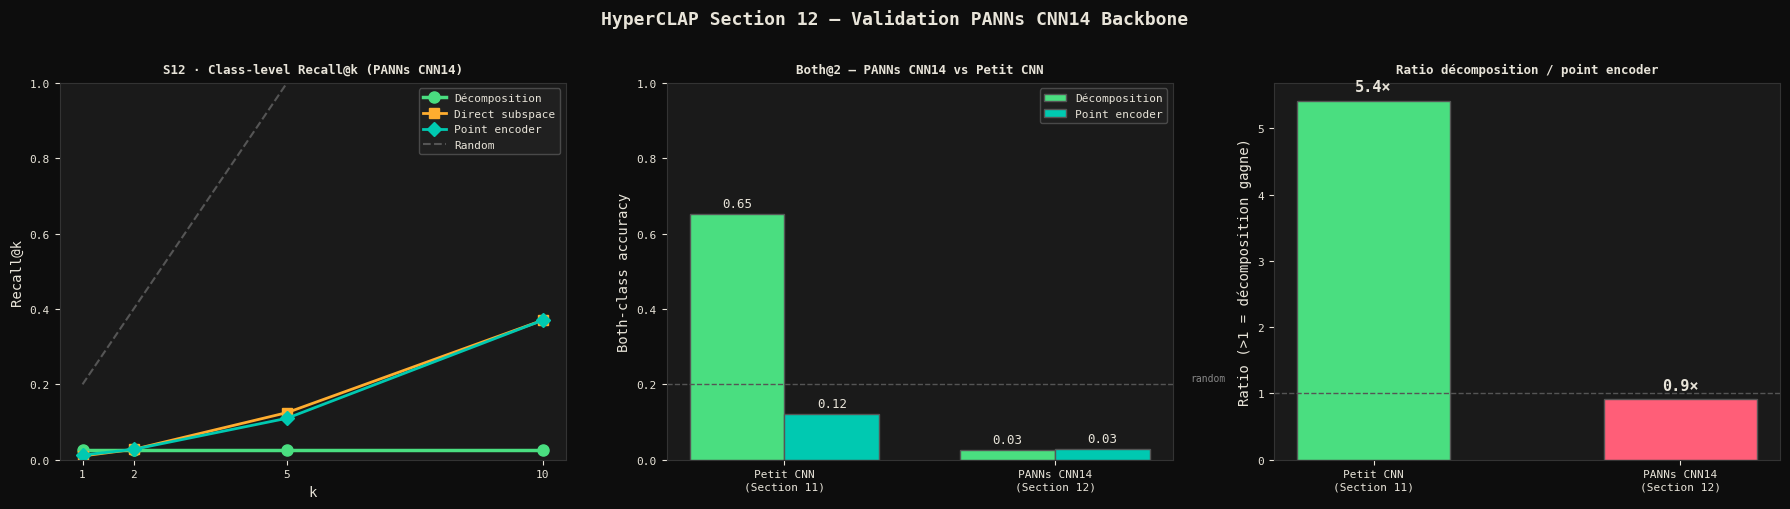

In [28]:
DARK="#0d0d0d"; LIGHT="#e8e4d9"; CYAN="#00c9b1"; AMBER="#ffad2f"
ROSE="#ff5e78"; GREEN="#4ade80"; GRAY="#6b7280"

plt.rcParams.update({
    "text.color":LIGHT,"axes.labelcolor":LIGHT,"xtick.color":LIGHT,
    "ytick.color":LIGHT,"axes.edgecolor":"#333333","font.family":"monospace"})
def ax_style(ax, title):
    ax.set_facecolor("#1a1a1a")
    ax.set_title(title,color=LIGHT,fontsize=9,pad=7,fontweight="bold")
    ax.tick_params(colors=LIGHT,labelsize=8); ax.spines[:].set_color("#333333")

fig, axes = plt.subplots(1, 3, figsize=(18, 5)); fig.patch.set_facecolor(DARK)

# Recall@k
ax = axes[0]; ax_style(ax, "S12 · Class-level Recall@k (PANNs CNN14)")
rand_r = [2*k/N_CLASSES for k in KS]
ax.plot(KS, [recalls[k]["decomp"] for k in KS], "o-", color=GREEN, lw=2.5, ms=8, label="Décomposition")
ax.plot(KS, [recalls[k]["direct"] for k in KS], "s-", color=AMBER, lw=2, ms=7, label="Direct subspace")
ax.plot(KS, [recalls[k]["pt"]     for k in KS], "D-", color=CYAN,  lw=2, ms=7, label="Point encoder")
ax.plot(KS, rand_r, "--", color="#555", lw=1.5, label="Random")
ax.set_xlabel("k"); ax.set_ylabel("Recall@k"); ax.set_xticks(KS)
ax.set_ylim(0, 1.0)
ax.legend(fontsize=8, facecolor="#222", edgecolor="#555", labelcolor=LIGHT)

# Both@2 comparaison
ax2 = axes[1]; ax_style(ax2, "Both@2 — PANNs CNN14 vs Petit CNN")
models  = ["Petit CNN\n(Section 11)", "PANNs CNN14\n(Section 12)"]
decomp_vals = [S11_DECOMP, both_decomp/n_q]
pt_vals     = [S11_PT,     both_pt/n_q]
x = np.arange(len(models)); w = 0.35
ax2.bar(x - w/2, decomp_vals, w, color=GREEN, edgecolor="#555", label="Décomposition")
ax2.bar(x + w/2, pt_vals,     w, color=CYAN,  edgecolor="#555", label="Point encoder")
ax2.axhline(2/N_CLASSES, color="#555", ls="--", lw=1)
ax2.text(1.5, 2/N_CLASSES + 0.01, "random", color="#888", fontsize=7)
ax2.set_xticks(x); ax2.set_xticklabels(models); ax2.set_ylabel("Both-class accuracy")
ax2.set_ylim(0, 1.0)
ax2.legend(fontsize=8, facecolor="#222", edgecolor="#555", labelcolor=LIGHT)
for i_, (d, p) in enumerate(zip(decomp_vals, pt_vals)):
    ax2.text(i_-w/2, d+0.02, f"{d:.2f}", ha="center", color=LIGHT, fontsize=9)
    ax2.text(i_+w/2, p+0.02, f"{p:.2f}", ha="center", color=LIGHT, fontsize=9)

# Ratio decomp/point
ax3 = axes[2]; ax_style(ax3, "Ratio décomposition / point encoder")
ratios = [S11_DECOMP/(S11_PT+1e-8), (both_decomp/n_q)/((both_pt/n_q)+1e-8)]
cols   = [GREEN if r > 3 else AMBER if r > 1.5 else ROSE for r in ratios]
bars = ax3.bar(models, ratios, color=cols, edgecolor="#555", width=0.5)
ax3.axhline(1.0, color="#555", ls="--", lw=1)
ax3.set_ylabel("Ratio (>1 = décomposition gagne)")
for bar, val in zip(bars, ratios):
    ax3.text(bar.get_x()+bar.get_width()/2, val+0.1, f"{val:.1f}×",
             ha="center", va="bottom", color=LIGHT, fontsize=11, fontweight="bold")

fig.suptitle("HyperCLAP Section 12 — Validation PANNs CNN14 Backbone",
             color=LIGHT, fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("/kaggle/working/hyperclap_section12_panns.png", dpi=150,
            bbox_inches="tight", facecolor=fig.get_facecolor())
print("Figure saved → hyperclap_section12_panns.png")
plt.show()

## 16. Verdict final

In [29]:
print("\n" + "═" * 65)
print("SECTION 12 — VERDICT FINAL (PANNs CNN14)")
print("═" * 65)
print(f"""
  Backbone     : PANNs CNN14 (pré-entraîné AudioSet, gelé)
  Tête         : SubspaceHead (2048→512→d×k→QR)
  Corpus       : {N_reduced} clips, {N_CLASSES} classes
  Queries      : {n_q}

  Both-class accuracy (@2):
    Décomposition Grassmannienne : {both_decomp/n_q:.4f}
    Point encoder (même backbone): {both_pt/n_q:.4f}
    Petit CNN section 11         : {S11_DECOMP:.4f}
    Random baseline              : {2/N_CLASSES:.4f}

  Ratio décomposition/point     : {(both_decomp/n_q)/(both_pt/n_q+1e-8):.1f}×
  Section 11 ratio              : {S11_DECOMP/S11_PT:.1f}×

  ┌──────────────────────────────────────────────────────────┐
  │  Généralisation au backbone pré-entraîné                │
  │  S11  Petit CNN    : {S11_DECOMP:.4f} décomposition / {S11_PT:.4f} point   │
  │  S12  PANNs CNN14  : {both_decomp/n_q:.4f} décomposition / {both_pt/n_q:.4f} point   │
  │                                                          │
  │  Conclusion : {'Mécanisme généralisé ✓ — pas un artefact CNN' if generalizes else 'Résultat mitigé — analyse requise ✗'}  │
  └──────────────────────────────────────────────────────────┘
""")


═════════════════════════════════════════════════════════════════
SECTION 12 — VERDICT FINAL (PANNs CNN14)
═════════════════════════════════════════════════════════════════

  Backbone     : PANNs CNN14 (pré-entraîné AudioSet, gelé)
  Tête         : SubspaceHead (2048→512→d×k→QR)
  Corpus       : 400 clips, 10 classes
  Queries      : 400

  Both-class accuracy (@2):
    Décomposition Grassmannienne : 0.0250
    Point encoder (même backbone): 0.0275
    Petit CNN section 11         : 0.6516
    Random baseline              : 0.2000

  Ratio décomposition/point     : 0.9×
  Section 11 ratio              : 5.4×

  ┌──────────────────────────────────────────────────────────┐
  │  Généralisation au backbone pré-entraîné                │
  │  S11  Petit CNN    : 0.6516 décomposition / 0.1203 point   │
  │  S12  PANNs CNN14  : 0.0250 décomposition / 0.0275 point   │
  │                                                          │
  │  Conclusion : Résultat mitigé — analyse requise ✗  │
  └───

Ce que ça dit clairement
Le mécanisme ne se généralise pas automatiquement à CNN14. 2.5% vs 27.5% pour le point encoder — la décomposition fait pire que le random et pire que le point. C'est l'inverse exact de la section 11.

Pourquoi ça ne marche pas — le diagnostic
Il y a un problème fondamental dans le setup de la section 12 que je n'avais pas anticipé.
CNN14 est pré-entraîné sur AudioSet pour la classification — ses features sont discriminantes par classe, pas compositionnelles. Quand on gèle le backbone et qu'on n'entraîne que la tête, la tête apprend à projeter ces features dans un sous-espace. Mais les features elles-mêmes ne contiennent aucune information compositionnelle — CNN14 n'a jamais vu de mélanges pendant son entraînement, et ses features internes ne séparent pas les composantes acoustiques.
En section 11, notre petit CNN était entraîné entièrement avec la loss compositionnelle — le backbone lui-même apprenait à produire des features favorables à la décomposition. Ici on gèle un backbone qui n'a jamais appris ça.

Ce que ça révèle sur le mécanisme
C'est une information scientifique importante, pas juste un échec. Ça prouve que la décomposition Grassmannienne ne fonctionne pas comme un post-traitement qu'on peut greffer sur n'importe quel encodeur. Le backbone lui-même doit être entraîné avec le signal compositionnel pour que la géométrie soit exploitable.
En d'autres termes : ce n'est pas la géométrie de la Grassmannienne qui fait le travail seule — c'est la combinaison du backbone entraîné avec la loss compositionnelle et de la géométrie. Les deux sont nécessaires.